# UNSUPERVISE LEARNING - PENGKLASIFIKASI COMMENT PROMOSI JUDI TERHADAP PODCAST INFLUENCER HITS PADA TAHUN 2026 

#### link yt:
##### https://youtu.be/MVuvPzJNnjk?si=7jqa11tlcueolw2 
##### https://www.youtube.com/watch?v=eOwtRnJemrg

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('D:/UNSUPERVISE LEARNING - JUDI YT/dataset-comments-yt.csv')

print("--- [UNDERSTANDING] TAMPILAN 5 DATA TERATAS ---")
print(df.head(), "\n")

print("--- [UNDERSTANDING] TAMPILAN 5 DATA TERATAS AFTER FILTERING ---")
df_using = df.drop(['authorIsChannelOwner', 'authorIsChannelOwner','commentsCount','hasCreatorHeart', 'pageUrl','replyToCid',
                'cid', 'title', 'type', 'videoId',], axis=1)
print(df_using.head(), "\n")

print("--- [UNDERSTANDING] INFORMASI STRUKTUR & TIPE DATA ---")
print(df_using.info(), "\n")


print("--- [UNDERSTANDING] RINGKASAN STATISTIK DESKRIPTIF ---")
print(df_using.describe(include='all'), "\n") #INCLUDE DATA KATEGORI

print("--- [UNDERSTANDING] JUMLAH MISSING VALUES PER KOLOM ---")
print(df_using.isnull().sum(), "\n")

print("--- [UNDERSTANDING] JUMLAH NaN VALUES PER KOLOM ---")
print(df_using.isna().sum(), "\n")

print("--- [UNDERSTANDING] JUMLAH data duplicated VALUES PER KOLOM ---")
print(df_using.duplicated().sum(), "\n")

print("--- [UNDERSTANDING] JUMLAH kolom dan baris ---")
print(df_using.shape, "\n")

--- [UNDERSTANDING] TAMPILAN 5 DATA TERATAS ---
               author  authorIsChannelOwner                         cid  \
0     @Sophiapandorah                 False  UgyRzHk4tC6rHYsZAkp4AaABAg   
1      @rudolfmanik68                 False  UgwHVyWhIabGOWRf0E14AaABAg   
2        @annamlpride                 False  Ugz-kx8NZUkHLp8ibkx4AaABAg   
3  @SajjatHossain-u8q                 False  Ugyc8Wrhbzq0IJdhtU14AaABAg   
4  @SajjatHossain-u8q                 False  Ugz_4ktvFUww3TFPluF4AaABAg   

                                             comment  commentsCount  \
0  Bang Medy udah berubah.\n \nDulu dia kalem. Re...            139   
1                            Baru tau ada podcastnya            139   
2  aku nonton bang jerome dari jaman smp,ga keras...            139   
3  Rezeki besar lagi-lagi datang dari P͟U͟L͟A͟U͟777.            139   
4  Dari kecil sampai gede JP, semua berawal dari𝙋...            139   

   hasCreatorHeart                                          pageUrl  \
0  

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1694 entries, 0 to 1693
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   author                1694 non-null   object
 1   authorIsChannelOwner  1694 non-null   bool  
 2   cid                   1694 non-null   object
 3   comment               1694 non-null   object
 4   commentsCount         1694 non-null   int64 
 5   hasCreatorHeart       1694 non-null   bool  
 6   pageUrl               1694 non-null   object
 7   publishedTimeText     1694 non-null   object
 8   replyCount            1694 non-null   int64 
 9   replyToCid            95 non-null     object
 10  title                 1694 non-null   object
 11  type                  1694 non-null   object
 12  videoId               1694 non-null   object
 13  voteCount             1694 non-null   int64 
dtypes: bool(2), int64(3), object(9)
memory usage: 162.2+ KB


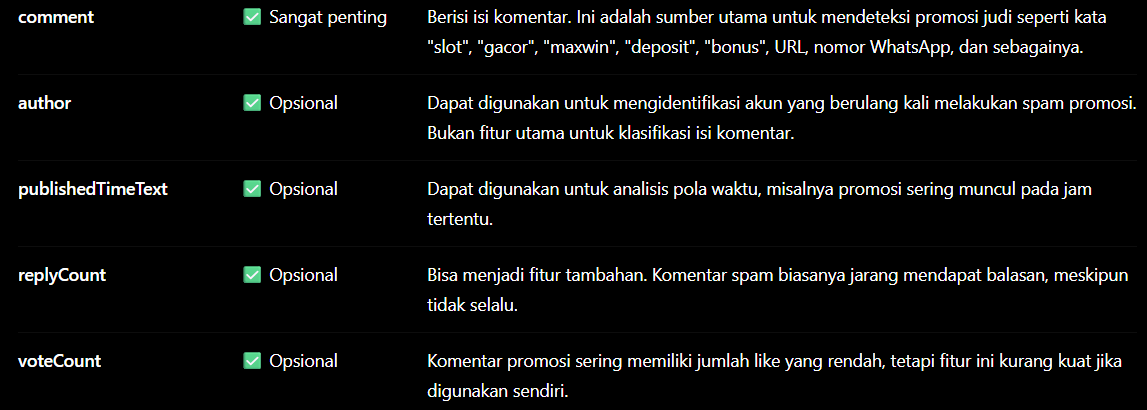

In [36]:
print(df_using[df_using.duplicated(keep=False)]) #melihat value yg duplicated

                      author  \
22             @DediJaya-s1g   
23             @DediJaya-s1g   
41          @shis.bhai.yt_01   
45          @shis.bhai.yt_01   
48          @shis.bhai.yt_01   
49          @shis.bhai.yt_01   
51          @shis.bhai.yt_01   
136           @Alamin2.2-t4g   
137           @Alamin2.2-t4g   
765         @ariswidyarahman   
766         @ariswidyarahman   
834              @oyycreator   
835              @oyycreator   
1140  @dedehasanibrahimy4679   
1141  @dedehasanibrahimy4679   
1142  @dedehasanibrahimy4679   
1143  @dedehasanibrahimy4679   
1367          @yodiputra8604   
1368          @yodiputra8604   

                                                comment publishedTimeText  \
22     13:44 ada privilege dok...privilege nya imortal😂         1 day ago   
23     13:44 ada privilege dok...privilege nya imortal😂         1 day ago   
41    Mengisi harimu lebih indah diＢＡＮ Ｔ ＥＮ ＧＨ Ｏ ＫＩ....       5 hours ago   
45    peminat terbanyakＢＡＮ Ｔ ＥＮ ＧＨ Ｏ ＫＩdi Indonesia

In [37]:
df_using.drop_duplicates(keep='first', inplace=True) #menghapus data yg duplicated
print(df_using[df_using.duplicated(keep=False)]) #melihat value yg duplicated

Empty DataFrame
Columns: [author, comment, publishedTimeText, replyCount, voteCount]
Index: []


In [38]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory



def cleaning_text(text):
  text = text.lower()

  text = re.sub(r'[^a-zA-Z0-9\s]','', text )

  tokens = word_tokenize(text)

  stop_words_removal = set(stopwords.words("indonesian"))
  tokens = [word for word in tokens if word not in stop_words_removal]


  Stemmer = StemmerFactory().create_stemmer()
  tokens = [Stemmer.stem(word) for word in tokens]

  hasil_akhir = ' '.join(tokens)
  return hasil_akhir

In [39]:
df_using['comment_after_cleansing'] = df_using['comment'].apply(lambda x: cleaning_text(x))

print(df_using['comment_after_cleansing'].head())
X_feature= df_using['comment_after_cleansing']

0    bang medy udah ubah kalem review main aja bare...
1                                       tau podcastnya
2    nonton bang jerome jaman smpga rasa dah kuliah...
3                             rezeki lagilagi pulau777
4                                      gede jp dari777
Name: comment_after_cleansing, dtype: object


In [40]:
cv = CountVectorizer()
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X_feature)
X_cv = cv.fit_transform(X_feature)

print(X_tfidf.toarray(),"\n")
print(X_cv.toarray(),"\n")
print(X_tfidf.shape)
print(len(tfidf.vocabulary_))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 

(1684, 5289)
5289


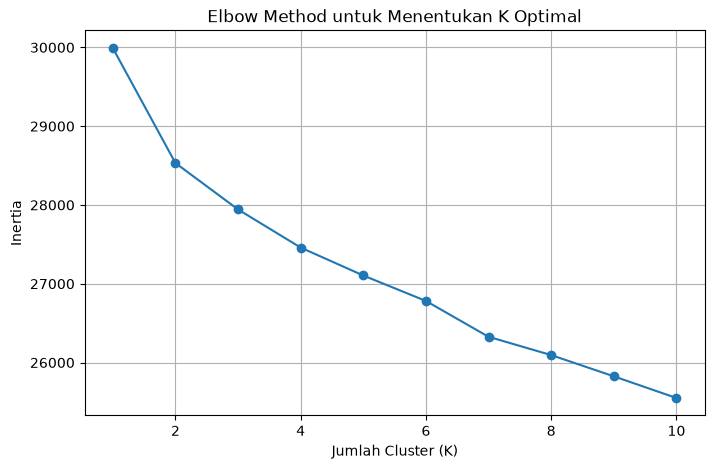

[29992.4578384798, 28532.592884819343, 27943.032247764993, 27459.092649092647, 27104.836079467947, 26781.53233642065, 26326.9069969396, 26094.73004194897, 25825.12655065666, 25550.02276196725]

K terbaik menurut silhouette: 1


In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# PERBAIKAN: Ambil kolom sebagai DataFrame agar baris = jumlah mahasiswa
col_num = X_cv

# 2. Elbow Method untuk mencari jumlah cluster terbaik
inertia_or_wcss = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(col_num)
    inertia_or_wcss.append(model.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_or_wcss, marker='o')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()
best_k = K_range[inertia_or_wcss.index(max(inertia_or_wcss))] 

print(inertia_or_wcss)        
print(f"\nK terbaik menurut silhouette: {best_k}")

K=2  ->  silhouette = 0.554
K=3  ->  silhouette = 0.548
K=4  ->  silhouette = 0.484
K=5  ->  silhouette = 0.429
K=6  ->  silhouette = 0.538
K=7  ->  silhouette = 0.297
K=8  ->  silhouette = 0.472
K=9  ->  silhouette = 0.458
K=10  ->  silhouette = 0.038


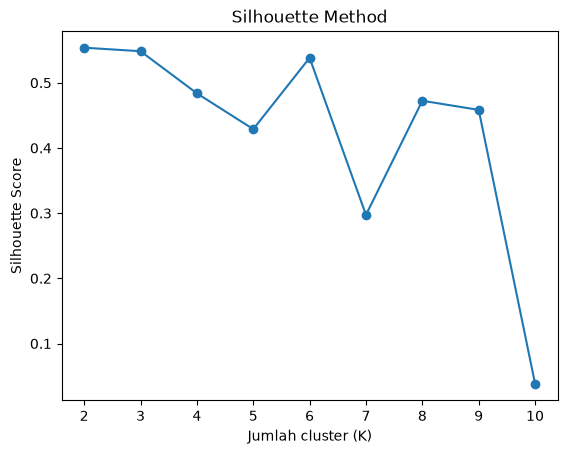


K terbaik menurut silhouette: 2


In [42]:
from sklearn.metrics import silhouette_score

# Tentukan rentang nilai K yang ingin diuji
scores = []
K_range = range(2, 11)

for k in K_range:
  model = KMeans(n_clusters=k, random_state = 42, n_init=10)
  labels = model.fit_predict(col_num)
  score = silhouette_score(col_num, labels)
  scores.append(score)
  print(f"K={k}  ->  silhouette = {score:.3f}")

# Gambar grafiknya
plt.plot(K_range, scores, marker='o')
plt.xlabel('Jumlah cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

# K terbaik = yang skornya paling tinggi
best_k = K_range[scores.index(max(scores))]
print(f"\nK terbaik menurut silhouette: {best_k}")

## USING K-MEANS

In [43]:
model = KMeans(n_clusters=5, random_state=42)
label_predict = model.fit_predict(col_num)
df_using['cluster'] = label_predict
df_using.head()
df_using['cluster'].sort_index().value_counts()

cluster
4    1521
1      98
0      54
3       9
2       2
Name: count, dtype: int64

C:\Users\ADVAN\AppData\Local\Temp\ipykernel_5344\2469917468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_using, x='cluster', palette='rocket')


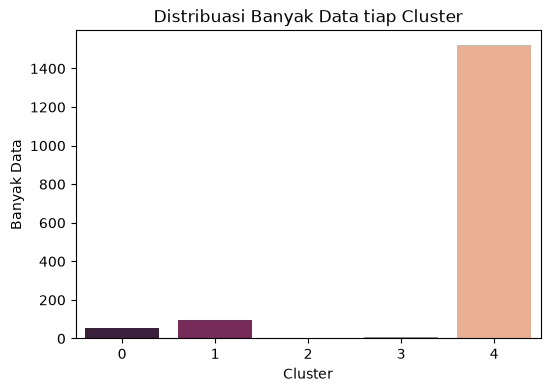

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_using, x='cluster', palette='rocket')
plt.title('Distribuasi Banyak Data tiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Banyak Data')
plt.show()

In [45]:
df_using.loc[df_using['cluster'] == 1,'comment_after_cleansing']
print(
    df_using.loc[
        df_using['cluster'] == 3,
        'comment_after_cleansing'
    ].to_string()
)

73      usaha 1 lulus bangku kuliah 2 motivator usaha ...
221     dok dar tamat smk langsung kerja ortu gak biay...
691     usaha investasi jangka maksud kerja orang tabu...
743     umur 23 fresh graduate bidang didik tinggal nu...
981     jari sukses faktor untung generasi milenial yg...
1090    bagus dok sampai gamblang jujur hibur ujung2ny...
1101    bener banget bilang dr tirta jalan hidup dr no...
1423    bener diomongin dr tirta gaada previlege kelua...
1445    kerja kuliah kerja freelance driver orang wisa...


In [51]:
df_using['label'] = 'Bukan PromosiJudi'

df_using.loc[df_using['cluster'] == 4, 'label'] = 'Promosi Judi'

In [47]:
df_using.head()

,author,comment,publishedTimeText,replyCount,voteCount,comment_after_cleansing,cluster,label
0,@Sophiapandorah,Bang Medy udah berubah.\n \nDulu dia kalem. Re...,1 hour ago (edited),0,1,bang medy udah ubah kalem review main aja bare...,4,Promosi Judi
1,@rudolfmanik68,Baru tau ada podcastnya,2 hours ago,0,0,tau podcastnya,4,Promosi Judi
2,@annamlpride,"aku nonton bang jerome dari jaman smp,ga keras...",2 hours ago,0,0,nonton bang jerome jaman smpga rasa dah kuliah...,4,Promosi Judi
3,@SajjatHossain-u8q,Rezeki besar lagi-lagi datang dari P͟U͟L͟A͟U͟777.,3 hours ago,0,0,rezeki lagilagi pulau777,4,Promosi Judi
4,@SajjatHossain-u8q,"Dari kecil sampai gede JP, semua berawal dari𝙋...",3 hours ago,0,0,gede jp dari777,4,Promosi Judi


In [48]:
df_using.to_csv('D:/UNSUPERVISE LEARNING - JUDI YT/dataset-comments-yt-after-clustering.csv', index=False)

## USING DBSCAN

In [49]:
from sklearn.cluster import DBSCAN

model = DBSCAN(
    eps=0.3,
    min_samples=5,
    metric='cosine' #'euclidean'
)

label_predict = model.fit_predict(col_num)

df2 = df_using.copy()
df2['cluster_dbscan'] = label_predict
df2['cluster_dbscan'] = df2['cluster_dbscan'].replace(-1, 1)
print(df2[['cluster_dbscan']].sort_index().value_counts())


print(df2.loc[df2['cluster_dbscan'] == 1, 'comment_after_cleansing'].to_string())

cluster_dbscan
1                 1620
4                   12
7                    9
5                    9
2                    7
3                    6
8                    6
0                    5
6                    5
9                    5
Name: count, dtype: int64
0       bang medy udah ubah kalem review main aja bare...
1                                          tau podcastnya
2       nonton bang jerome jaman smpga rasa dah kuliah...
3                                rezeki lagilagi pulau777
5       pu la u777emang benerbener ngasih hasil real o...
6                  sore cuan deras berkat777yang gak zonk
7                                pulau777jadi hoki minggu
8                                 maxwyn lagilagi dari777
9                         rezeki ngalir pu l au 7 7 7 aja
10          gak bohong 777emang ngasih sensasi cuan batas
11                10 menit main di777langsung ledak hasil
12                    pulau777emang raja jepe cepat drama
13                  saldo langsun

C:\Users\ADVAN\AppData\Local\Temp\ipykernel_5344\944546573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x='cluster_dbscan', palette='rocket')


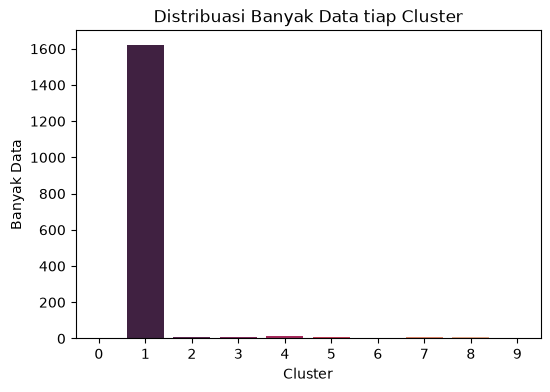

In [50]:

plt.figure(figsize=(6,4))
sns.countplot(data=df2, x='cluster_dbscan', palette='rocket')
plt.title('Distribuasi Banyak Data tiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Banyak Data')
plt.show()